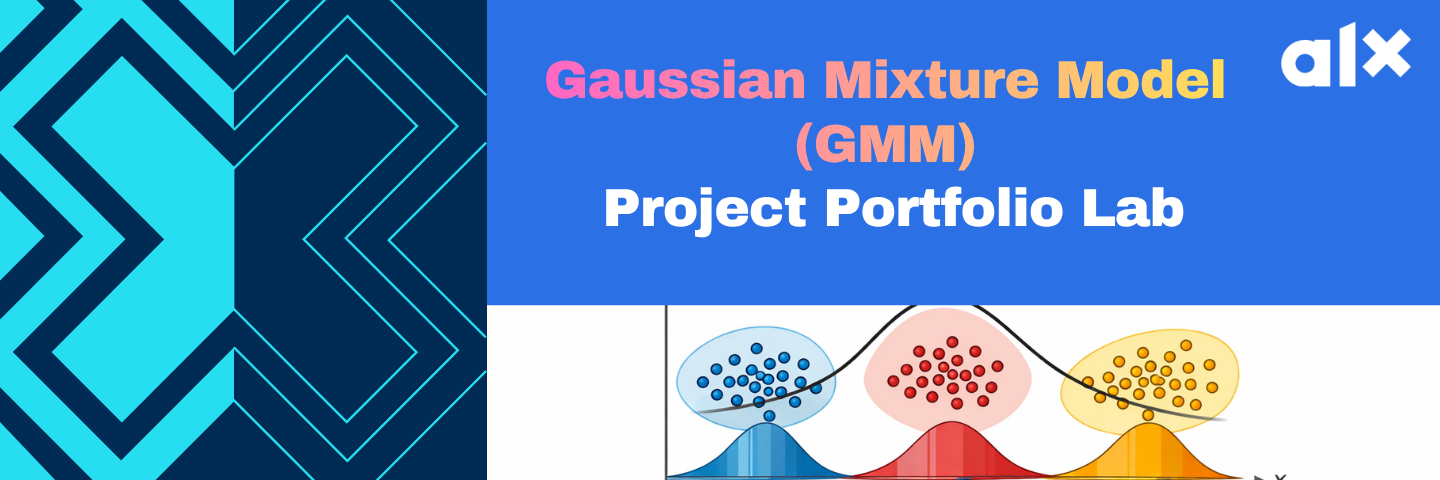

© **2026 ALX. All rights reserved.**

# Learning Outcome
- Understand Gaussian Mixture Model (GMM)
- Use Gaussian Mixture Model (GMM) to flag fraudulent transactions

# Introduction
A **Gaussian Mixture Model (GMM)** is a **probabilistic model** used in statistics and machine learning to represent a dataset as a combination of multiple Gaussian (normal) distributions with unknown parameters.

Think of it as a more flexible version of K-Means. While K-Means assigns a data point to exactly one cluster (hard clustering), GMM gives you the probability that a point belongs to each cluster (soft clustering).

## Intuition (Core Idea)

Instead of assuming your data comes from a single distribution, a GMM assumes:

> “Your data is generated from **several overlapping normal distributions**, each representing a hidden group (cluster).”

Each of these distributions is called a **component**.



## Visual Concept

![Image](https://images.openai.com/static-rsc-4/yhsu2qvSB5KnOOaJlIQsFdmUuK3ukn-ifmmUdZuUCq_46MOkCfSKw7P1O8Hws5FH9s2win5CaAuWu_DEWyyak0yI05iWNTDT_asIN2txr83juOH-C1x-vsEyPeZtG47FmO-SpZCLb277IqfRcVoWOrQgDeNrejn8vDk5SX53WSk5RGafsLashMesqdU2w_cz?purpose=fullsize)



![Image](https://images.openai.com/static-rsc-4/uFSieQEmTNO6-DwwdmAUCNC2PGK7VJLB5vIfOFsI8pNHPWRL17f2JS3xpGgN_Q6t8HZQrUYVs8Kw9TWtHbktM6P-FRh18YnLWyu5nrooKv9dgHP08RwuaVg2sk7ZGJtVS6F6mN0UELVtuzjVMkLfAPfCbSbba_MLbXGjU93PYgvjUABTtIQuyky6x9tW7Zgk?purpose=fullsize)



![Image](https://images.openai.com/static-rsc-4/U7AXGBmZQfOH8qLpKyiyxJkpD_-W9PVWG3mWM78-BMImD3wl9_xsNpIy2AyVoTt8DvBLwR4ml-P1UFj_XlXyuXqvur4BPc49XQFVrhzqSh-adTaGKOFpzVjbMKRdUWxuv_2ap1UUSq_dM7korTxI1Ukq1mWgiqnD5zU7tDYqT9EZ57lgE6ykBbWC1AoZn0OM?purpose=fullsize)

* Each colored shape = one Gaussian component
* Overlap = uncertainty / shared regions
* The combined curve = overall data distribution



## Mathematical Formulation

A GMM models the probability of a data point (x) as:

$$
P(x) = \sum_{k=1}^{K} \pi_k \cdot N(x \mid \mu_k, \Sigma_k)
$$

Where:

- $K$: number of components (clusters)  
- $\pi_k$: **mixing coefficient** (weight of each Gaussian, sums to 1)  
- $\mu_k$: **mean** (center of cluster)  
- $\Sigma_k$: **covariance matrix** (shape & spread of cluster)  
- ${N}$: Gaussian (normal) distribution  




## Key Characteristics

### 1. Soft Clustering

Unlike K-Means:

* GMM assigns **probabilities**, not hard labels
* A point can belong to multiple clusters with different likelihoods

Example:

* Point A → 70% Cluster 1, 30% Cluster 2



### 2. Flexible Cluster Shapes

* Can model **elliptical clusters** (via covariance)
* Not limited to circular clusters like K-Means


### 3. Probabilistic Foundation

* Provides a full **density estimation**, not just grouping
* Useful for anomaly detection and generative modeling



## How GMM is Trained

GMM typically uses the **Expectation-Maximization (EM) algorithm**:

1. **Expectation (E-step)**
   Estimate probability of each point belonging to each cluster

2. **Maximization (M-step)**
   Update parameters $(\pi, \mu, \Sigma)$ based on those probabilities

Repeat until convergence.


## When to Use GMM

Use GMM when:

* Clusters **overlap**
* Clusters are **not spherical**
* You need **probabilistic assignments**
* You want **density estimation**



## Comparison with K-Means

| Feature       | GMM                     | K-Means            |
| ------------- | ----------------------- | ------------------ |
| Assignment    | Soft (probabilities)    | Hard (one cluster) |
| Cluster shape | Elliptical              | Circular           |
| Output        | Distribution + clusters | Clusters only      |
| Algorithm     | EM                      | Lloyd’s algorithm  |



## Typical Applications

* Fraud detection (e.g., credit card anomalies)
* Customer segmentation
* Image segmentation
* Speech recognition
* Density estimation

---

# **Project: Catching Fraudsters with Gaussian Mixtures**

Imagine you are a **data detective** 👮 at **Pigeon Bank PLC**. Every day, millions of transactions flow through the system—some are perfectly legitimate, but others are fraudulent. These fraudulent transactions can **cause real harm**: customers might lose their money, credit can be damaged, and trust in the bank erodes. For the bank, fraud means financial losses, operational headaches, and reputational damage. You can’t manually check every transaction—but what if your computer could spot the suspicious ones automatically? Today, we’ll use a tool called Gaussian Mixture Model to uncover hidden patterns in the data and flag fraud before it hurts anyone.

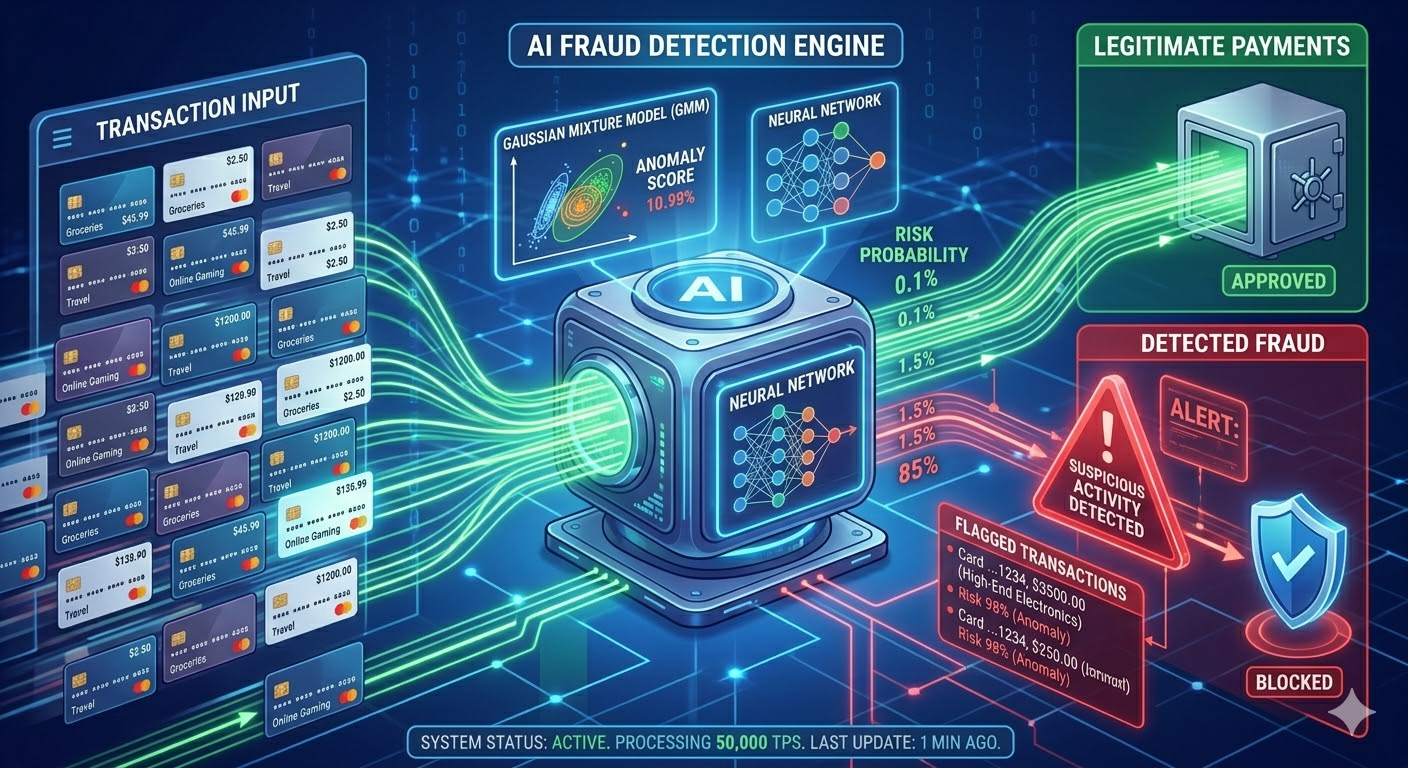

## About the dataset
The Credit Card Fraud Dataset is available on [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data) and contains anonymized transactions made by European cardholders. It includes numerical features representing transaction details (like **`amount`**, **`time`**, and **`PCA-transformed variables`**) and a target label indicating whether a transaction is **`fraudulent (1)`** or **`legitimate (0)`**. The **'Time'** feature contains the seconds elapsed between each transaction and the first transaction in the dataset.

The dataset can be downloaded in zip format from this [link](https://drive.google.com/file/d/16edtzjftwrJ6paBsN3rpM25wkzCuuOkm/view?usp=drive_link) or in csv format from this [link](https://drive.google.com/file/d/1t93aKuaGcbpbLqrQYNz3fSInvPTSpXYa/view?usp=drive_link).

You can also load the dataset directly from Kaggle thus:


#### Step 1: Sign in to Kaggle

* Go to [Kaggle](https://www.kaggle.com/) and log in with your account.



#### Step 2: Go to Account Settings

* Click your profile picture → **Account**.



#### Step 3: Create API Token

* Scroll down to the **API** section.
* Click **Create New API Token**.
* This will download a file called **`kaggle.json`**.



#### Step 4: Store the API Key

* The `kaggle.json` contains your **username** and **API key**.
* Keep it **safe and private**; don’t share it publicly.



#### Step 5: Use the API Key

* In Python or Colab, you can place `kaggle.json` in `~/.kaggle/` (Linux/Mac) or `/root/.kaggle/` (Colab) and set permissions:

```bash
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
```

* Then you can download datasets:

```bash
!kaggle datasets download -d <dataset-name>
```




## Load the dataset

- **Import the necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

import matplotlib.pyplot as plt

- **Load the dataset directly from Kaggle**

In [ ]:
# 1. Create a hidden directory for the token
!mkdir -p ~/.kaggle

# 2. Move the file and set permissions
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Replace with the command you copied
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 230MB/s]



- **Unzip the dataset**

In [ ]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


- **Load the dataset into a dataframe**

In [ ]:
df = pd.read_csv('creditcard.csv')

## Exploratory Data Analysis (EDA)

In [ ]:
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
display(df.tail())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1081


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
num_duplicates_after_drop = df.duplicated().sum()
print(f"Number of duplicate rows after dropping: {num_duplicates_after_drop}")

Number of duplicate rows after dropping: 0


In [ ]:
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_info.empty:
    print('No missing values found in the dataset.')
else:
    display(missing_info)

No missing values found in the dataset.


### Feature Engineering from 'Time' Column

We will extract 'Hour' and 'Day' features from the 'Time' column. The 'Time' column is in seconds, so we'll convert it to hours and then derive the hour of the day and a sequential day number.

In [ ]:
# Convert 'Time' from seconds to hours
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))

# Create a 'Day' feature (assuming time starts from day 0)
df['Day'] = df['Time'].apply(lambda x: np.floor(x / (24 * 3600)))

print("New features 'Hour' and 'Day' created successfully.")
display(df[['Time', 'Hour', 'Day']].head())

New features 'Hour' and 'Day' created successfully.


,Time,Hour,Day
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,2.0,0.0,0.0


- **Check class distribution**

In [ ]:
x = df['Class'].value_counts().index

In [ ]:
y = df['Class'].value_counts().values

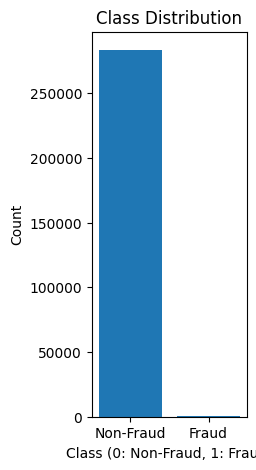

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,5))
plt.bar(x, y)
plt.title('Class Distribution')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

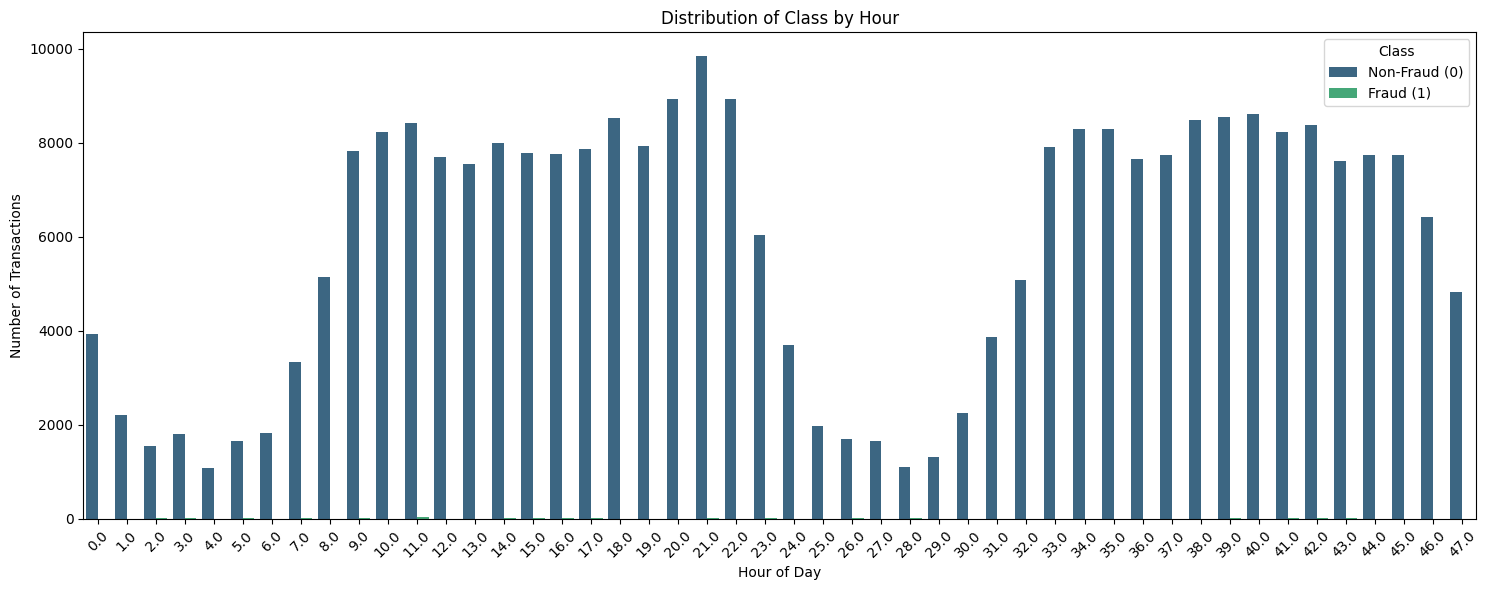

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='Hour', hue='Class', palette='viridis')
plt.title('Distribution of Class by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Class', labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

### Prepare and Scale the Data

First, we separate the features (X) from the target variable (y). Then, we scale the features using `StandardScaler` to standardize them. This is important for many machine learning algorithms, including GMM, as it ensures that features with larger values do not disproportionately influence the model.

In [ ]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of original features (X):", X.shape)
print("Shape of scaled features (X_scaled):", X_scaled.shape)

Shape of original features (X): (283726, 32)
Shape of scaled features (X_scaled): (283726, 32)


### Apply GMM

**Steps**

1. Prepare and scale the data
2. Train GMM on normal transactions
3. Choose optimal number of components with BIC
4. Compute log-likelihood for all transactions
5. Set threshold to identify anomalies
6. Convert scores to binary predictions
7. Evaluate performance

In [ ]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

### Determine Optimal Number of Components for GMM

To find the optimal number of components for the Gaussian Mixture Model, we will iterate through a range of possible component numbers and calculate the Bayesian Information Criterion (BIC) for each. The model with the lowest BIC is generally preferred as it indicates a better balance between model fit and complexity.

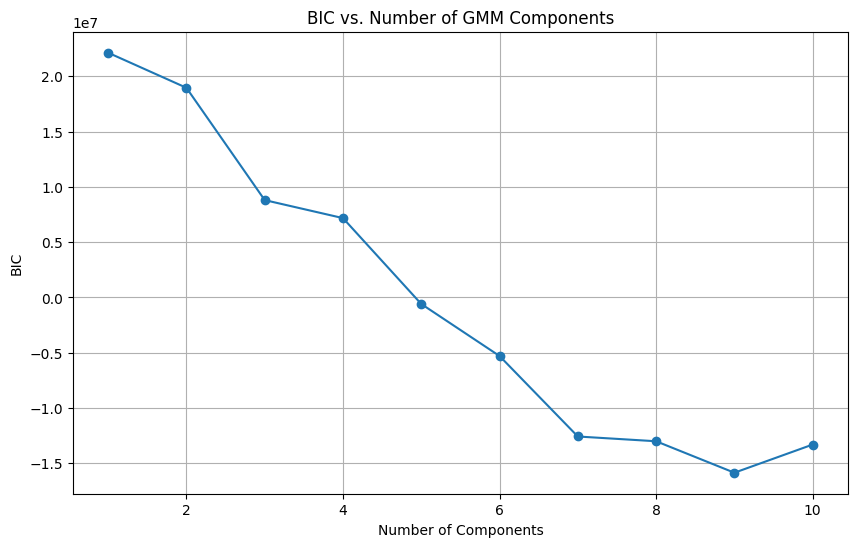

Optimal number of components based on BIC: 9


In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np

n_components = np.arange(1, 11)  # Test 1 to 10 components
bics = []

for n_comp in n_components:
    gmm = GaussianMixture(n_components=n_comp, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))

# Plot the BIC values
plt.figure(figsize=(10, 6))
plt.plot(n_components, bics, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('BIC vs. Number of GMM Components')
plt.grid(True)
plt.show()

optimal_components = n_components[np.argmin(bics)]
print(f"Optimal number of components based on BIC: {optimal_components}")

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Filter Legitimate Transactions**

In [ ]:
# Filter out the fruadulent transactions
X_normal = X_scaled[y == 0]

- GMM is trained only on normal (legitimate) transactions
- Fraud is rare, so we treat it as an anomaly

In [ ]:
# Choose optimal number of components with BIC
bic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    # Fit the GMM on normal transactions (X_normal)
    gmm.fit(X_normal)
    bic_scores.append(gmm.bic(X_normal))

# Select best K
best_k = k_range[np.argmin(bic_scores)]
print("Best number of components:", best_k)

Best number of components: 9


In [ ]:
# Initialise the GMM class
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=23
)

In [ ]:
# fit the data on to the gmm
gmm.fit(X_normal)

GaussianMixture(n_components=3, random_state=42)

In [ ]:
# Find the likelihood
log_likelihood = gmm.score_samples(X_scaled)

- Measures how likely each transaction is under the “normal behavior” model
- Low log-likelihood → unusual transaction → potential fraud

**Determine Anomaly Threshold**

In [ ]:
# Select threshold to identify fraud
threshold = np.percentile(log_likelihood, 1)

- Uses the 1st percentile as cutoff
- Transactions below this threshold are flagged as fraud

**Generate Binary Predictions**

In [ ]:
y_pred = (log_likelihood < threshold).astype(int)

- Converts log-likelihood scores into 0/1 labels
- 1 → predicted fraud, 0 → predicted legitimate

**Evaluate Model Performance**

In [ ]:
print(classification_report(y, y_pred))
print("ROC-AUC:", roc_auc_score(y, -log_likelihood))

- classification_report → precision, recall, F1-score for fraud detection
- ROC-AUC → overall ability to distinguish fraud vs legit
- -log_likelihood is used because lower likelihood → more likely fraud

In [ ]:
pd.DataFrame([y, y_pred]).T

,Class,Unnamed 0
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
284802,0,1
284803,0,0
284804,0,0
284805,0,0


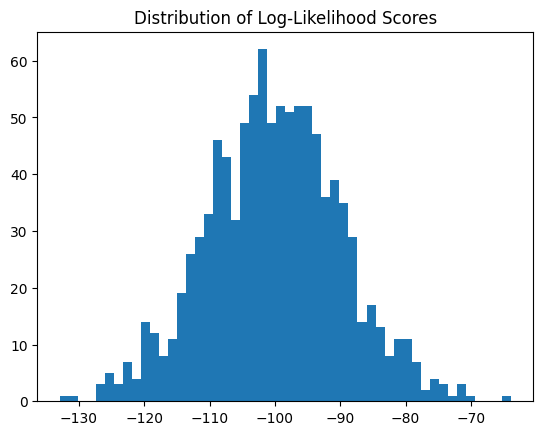

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for 'scores'. Replace with your actual data.
scores = np.random.normal(loc=-100, scale=10, size=1000)

plt.hist(scores, bins=50)
plt.title("Distribution of Log-Likelihood Scores")
plt.show()

## 🧾 Final Summary & Conclusion

In this project, we developed an **unsupervised anomaly detection model** using a **Gaussian Mixture Model (GMM)** to identify potentially fraudulent credit card transactions.

### 🔍 Key Achievements

- Successfully applied **unsupervised learning** on a highly imbalanced dataset  
- Modeled the distribution of normal transactions using GMM  
- Detected anomalies based on **log-likelihood (probability scores)**  
- Identified suspicious transactions without relying on labeled data  

---

### 📊 Insights

- Fraudulent transactions tend to have **low probability under the learned distribution**  
- GMM effectively captures the **underlying structure of normal behavior**  
- Some false positives are expected due to the nature of anomaly detection  

---

### ⚠️ Limitations

- Performance depends heavily on **threshold selection**  
- May misclassify rare but legitimate transactions as anomalies  
- Not optimized for real-time detection  

---

### 🚀 Future Improvements

- Compare with:
  - Isolation Forest  
  - Autoencoders  
- Optimize threshold using ROC curve  
- Deploy as a **real-time fraud detection system**  
- Build a **dashboard for monitoring anomalies**  

---

### 🎯 Conclusion

This project demonstrates that **Gaussian Mixture Models are a powerful tool for anomaly detection**, especially in scenarios where labeled data is scarce.

It highlights how unsupervised learning can be applied to solve **real-world financial fraud problems** effectively.